In [18]:
# Cell 1: Imports
import sys
sys.path.append('../src')

import yfinance as yf
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import yfinance as yf
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from statsmodels.tsa.stattools import adfuller


def compute_zscore(spread, window):
    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()
    zscore = (spread - rolling_mean) / rolling_std
    return zscore



def generate_signal(zscore, entry_threshold = 2, exit_threshold = 0.5):
    raw_signal = pd.Series(np.nan, index = zscore.index)
    raw_signal[zscore > entry_threshold] = - 1
    raw_signal[zscore < -entry_threshold] = 1
    raw_signal[zscore.abs() < exit_threshold] = 0
    position = raw_signal.ffill().fillna(0)
    return position


def rolling_hedge_ratio(price_a, price_b, window):
    betas = pd.Series(index = price_a.index, dtype = float)
    for i in range(window, len(price_a)):
        y = price_a.iloc[i-window:i]
        x = price_b.iloc[i-window:i]
        X = sm.add_constant(x)
        model = sm.OLS(y,X).fit()
        betas.iloc[i] = model.params.iloc[1]
    return betas


def backtest(spread, position):
    spread_change = spread.diff()
    strategy_returns = position.shift(1) * spread_change
    return strategy_returns




In [19]:
# Cell 2: Download data
df_a = yf.download('MA', start='2020-01-01', end='2025-01-01')['Close']['MA']
df_b = yf.download('V', start='2020-01-01', end='2025-01-01')['Close']['V']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [20]:
# Cell 3: OLD approach — fixed beta using the WHOLE dataset (Day 4/6 method, has lookahead bias)
X = sm.add_constant(df_b)
model = sm.OLS(df_a, X).fit()
fixed_beta = model.params.iloc[1]
print("Fixed beta (whole dataset):", fixed_beta)

old_spread = df_a - (fixed_beta * df_b)
old_zscore = compute_zscore(old_spread, window=60)
old_position = generate_signal(old_zscore, entry_threshold=2, exit_threshold=0.5)

old_strategy_returns = backtest(old_spread, old_position)
old_cumulative_pnl = old_strategy_returns.cumsum()

Fixed beta (whole dataset): 1.8277176951112142


In [21]:
# Cell 4: NEW approach — rolling beta, recalculated through time using only past data (lookahead-safe)
rolling_beta = rolling_hedge_ratio(df_a, df_b, window=120)

new_spread = df_a - (rolling_beta * df_b)
new_zscore = compute_zscore(new_spread, window=120)
new_position = generate_signal(new_zscore, entry_threshold=2, exit_threshold=0.5)
new_strategy_returns = backtest(new_spread, new_position)
new_cumulative_pnl = new_strategy_returns.cumsum()

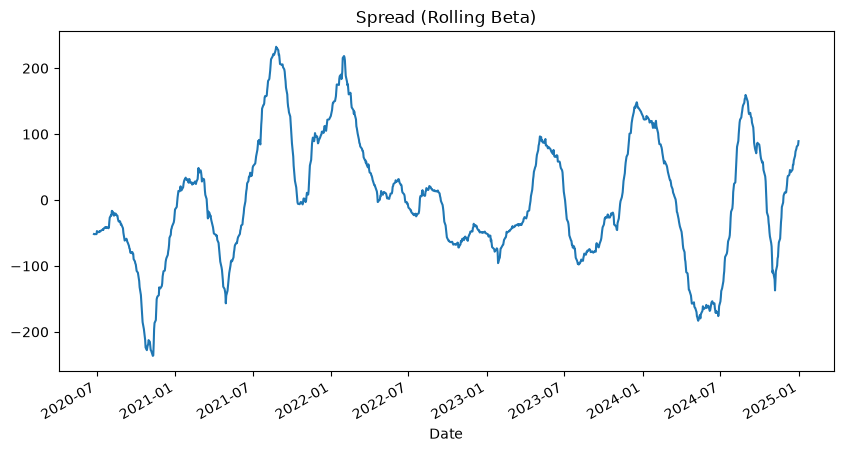

In [22]:
# Cell 5: Sanity-check the new spread and z-score visually
new_spread.plot(figsize=(10,5), title="Spread (Rolling Beta)")
plt.show()

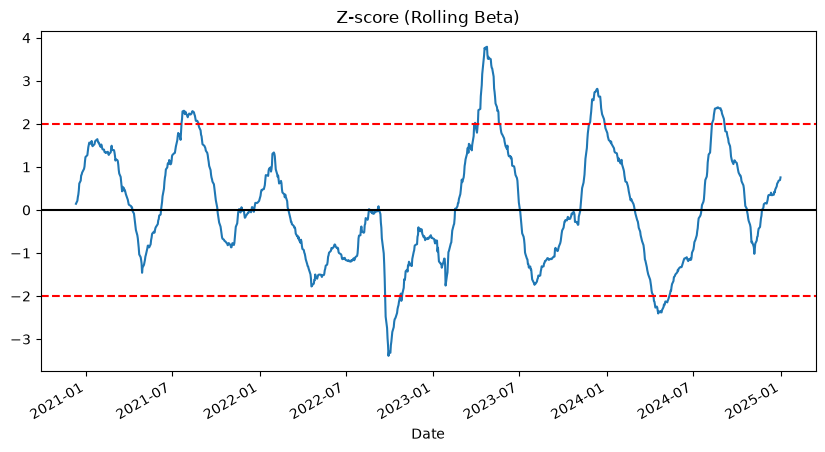

In [23]:
# Cell 6: Z-score with threshold lines
new_zscore.plot(figsize=(10,5), title="Z-score (Rolling Beta)")
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.axhline(0, color='black', linestyle='-')
plt.show()

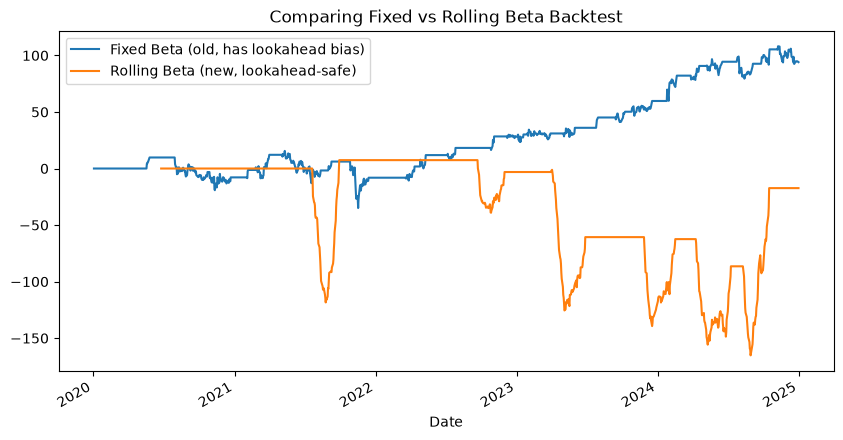

In [24]:
# Cell 7: Compare old vs new P&L
old_cumulative_pnl.plot(figsize=(10,5), label="Fixed Beta (old, has lookahead bias)")
new_cumulative_pnl.plot(label="Rolling Beta (new, lookahead-safe)")
plt.legend()
plt.title("Comparing Fixed vs Rolling Beta Backtest")
plt.show()